# Project: Investigate a Dataset - Movie Profitability (TMDb)

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 
This project uses the TMDb movie dataset. The dataset contains information for movies released from 1960 to 2015.  It includes movie details such as title, release year, genre, runtime, popularity, user ratings, vote counts, budget, revenue, and inflation-adjusted budget and revenue. 

For this project, I'm focusing on movie profitability. Since the movies were released across many decades, I'll use the inflation-adjusted budget and revenue columns to calculate profit, making older and newer movies easier to compare. 

##### The main dependent variable for this analysis is:
`profit_adj = revenue_adj - budget_adj`

This means adjusted profit is calculated as adjusted revenue minus adjusted budget. 

### Column Description

- `id`: Unique TMDb movie ID.
- `imdb_id`: Movie ID from IMDb.
- `popularity`: TMDb popularity score.
- `budget`: Original movie budget.
- `revenue`: Original movie revenue.
- `original_title`: Movie title.
- `cast`: Main cast members.
- `homepage`: Movie website, when available.
- `director`: Movie director.
- `tagline`: Movie tagline.
- `keywords`: Keywords connected to the movie.
- `overview`: Short movie description.
- `runtime`: Movie length in minutes.
- `genres`: Movie genre or genres.
- `production_companies`: Companies that produced the movie.
- `release_date`: Movie release date.
- `vote_count`: Number of TMDb user votes.
- `vote_average`: Average TMDb user rating.
- `release_year`: Year the movie was released.
- `budget_adj`: Budget adjusted for inflation.
- `revenue_adj`: Revenue adjusted for inflation.

### Questions for Analysis
##### Which movie characteristics are associated with higher adjusted profit?
1. How is adjusted profit distributed across the movies with complete financial data?
2. Do higher adjusted budgets tend to relate to higher adjusted profits?
3. How do popularity, vote count, and vote average relate to adjusted profit?

In [1]:
# Import packages for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Make larger tables easier to read in the notebook
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

<a id='wrangling'></a>
## Data Wrangling
In this section, I'll load the dataset, inspect its structure, check for missing values and duplicates, and identify values that need cleaning before analysis. 

In [2]:
# Load the TMDb movie dataset
movies = pd.read_csv('tmdb-movies.csv')

# Display the first few rows
movies.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.99,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.50,2015,"137,999,939.28","1,392,445,892.52"
1,76341,tt1392190,28.42,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,future|chase|post-apocalyptic|dystopia|australia,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.10,2015,"137,999,939.28","348,161,292.49"
2,262500,tt2908446,13.11,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,based on novel|revolution|dystopia|sequel|dyst...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.30,2015,"101,199,955.47","271,619,025.41"
3,140607,tt2488496,11.17,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,android|spaceship|jedi|space opera|3d,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.50,2015,"183,999,919.04","1,902,723,129.80"
4,168259,tt2820852,9.34,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,car race|speed|revenge|suspense|car,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.30,2015,"174,799,923.09","1,385,748,801.47"


In [3]:
# Check the shape of the dataset
movies.shape

(10866, 21)

In [4]:
# Check column names, data types, and non-null values
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [5]:
movies.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,"10,866.00","10,866.00","10,866.00","10,866.00","10,866.00","10,866.00","10,866.00","10,866.00","10,866.00","10,866.00"
mean,"66,064.18",0.65,"14,625,701.09","39,823,319.79",102.07,217.39,5.97,"2,001.32","17,551,039.82","51,364,363.25"
std,"92,130.14",1.00,"30,913,213.83","117,003,486.58",31.38,575.62,0.94,12.81,"34,306,155.72","144,632,485.04"
min,5.00,0.00,0.00,0.00,0.00,10.00,1.50,"1,960.00",0.00,0.00
25%,"10,596.25",0.21,0.00,0.00,90.00,17.00,5.40,"1,995.00",0.00,0.00
50%,"20,669.00",0.38,0.00,0.00,99.00,38.00,6.00,"2,006.00",0.00,0.00
75%,"75,610.00",0.71,"15,000,000.00","24,000,000.00",111.00,145.75,6.60,"2,011.00","20,853,251.08","33,697,095.72"
max,"417,859.00",32.99,"425,000,000.00","2,781,505,847.00",900.00,"9,767.00",9.20,"2,015.00","425,000,000.00","2,827,123,750.41"


In [6]:
# Count missing values by column
movies.isna().sum().sort_values(ascending=False)

homepage                7930
tagline                 2824
keywords                1493
production_companies    1030
cast                      76
director                  44
genres                    23
imdb_id                   10
overview                   4
budget_adj                 0
release_year               0
vote_average               0
vote_count                 0
release_date               0
id                         0
runtime                    0
original_title             0
revenue                    0
budget                     0
popularity                 0
revenue_adj                0
dtype: int64

In [7]:
# Check for duplicate rows
movies.duplicated().sum()

1

In [8]:
# Check for zero values in columns where zero is likely missing or unusable
zero_check_columns = ['budget', 'revenue', 'runtime', 'budget_adj', 'revenue_adj']
(movies[zero_check_columns] == 0).sum()

budget         5696
revenue        6016
runtime          31
budget_adj     5696
revenue_adj    6016
dtype: int64

### Data Wrangling Findings
The original dataset contains 10,866 rows and 21 columns. Several columns have missing values, especially `homepage`, `tagline`, `keywords`, and `production_companies`.

There's one duplicate row, and many rows have zero values for `budget`, `revenue`, `budget_adj`, or `revenue_adj`.  For a financial analysis, those zero values are a problem because profit can't be calculated correctly if they are missing. 

There's also some movies with a runtime of zero. Since movies can't have zero runtime, those rows will be removed.  

### Data Cleaning
For this analysis, I'll will clean the data in these steps:
1. Remove duplicate rows. 
2. Keep only the columns needed. 
3. Remove rows with missing genre values. 
4. Remove rows with zero runtime. 
5. Create a separate profit-focused dataframe using only rows where `budget_adj` and `revenue_adj` are both greater than zero.
6. Create the new columns `profit_adj`, and `profit`.
7. Create easier-to-read columns in millions for `budget`, `revenue`, and `adjusted profit`.

In [9]:
# Make a copy so the original dataframe stays unchanged
movies_clean = movies.copy()

# Remove duplicate rows
movies_clean = movies_clean.drop_duplicates()

# Keep only the columns needed for the analysis
columns_to_keep = [
    'id', 'original_title', 'popularity', 'budget', 'revenue', 'runtime',
    'genres', 'vote_count', 'vote_average', 'release_year',
    'budget_adj', 'revenue_adj']
movies_clean = movies_clean[columns_to_keep]

# Remove rows with missing genre values and zero runtime
movies_clean = movies_clean.dropna(subset=['genres'])
movies_clean = movies_clean.query('runtime > 0')

# Create a profit-focused dataframe.
# Profit requires both adjusted budget and adjusted revenue, so zero values are removed.
profit_movies = movies_clean.query('budget_adj > 0 and revenue_adj > 0').copy()

# Create profit columns
profit_movies['profit_adj'] = profit_movies['revenue_adj'] - profit_movies['budget_adj']
profit_movies['profit'] = profit_movies['revenue'] - profit_movies['budget']

# Create columns in millions so charts are easier to read
profit_movies['budget_adj_millions'] = profit_movies['budget_adj'] / 1_000_000
profit_movies['revenue_adj_millions'] = profit_movies['revenue_adj'] / 1_000_000
profit_movies['profit_adj_millions'] = profit_movies['profit_adj'] / 1_000_000

profit_movies.head()

,id,original_title,popularity,budget,revenue,runtime,genres,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj,profit,budget_adj_millions,revenue_adj_millions,profit_adj_millions
0,135397,Jurassic World,32.99,150000000,1513528810,124,Action|Adventure|Science Fiction|Thriller,5562,6.50,2015,"137,999,939.28","1,392,445,892.52","1,254,445,953.24",1363528810,138.00,"1,392.45","1,254.45"
1,76341,Mad Max: Fury Road,28.42,150000000,378436354,120,Action|Adventure|Science Fiction|Thriller,6185,7.10,2015,"137,999,939.28","348,161,292.49","210,161,353.21",228436354,138.00,348.16,210.16
2,262500,Insurgent,13.11,110000000,295238201,119,Adventure|Science Fiction|Thriller,2480,6.30,2015,"101,199,955.47","271,619,025.41","170,419,069.94",185238201,101.20,271.62,170.42
3,140607,Star Wars: The Force Awakens,11.17,200000000,2068178225,136,Action|Adventure|Science Fiction|Fantasy,5292,7.50,2015,"183,999,919.04","1,902,723,129.80","1,718,723,210.76",1868178225,184.00,"1,902.72","1,718.72"
4,168259,Furious 7,9.34,190000000,1506249360,137,Action|Crime|Thriller,2947,7.30,2015,"174,799,923.09","1,385,748,801.47","1,210,948,878.38",1316249360,174.80,"1,385.75","1,210.95"


In [10]:
# Compare the original and cleaned dataframe sizes
cleaning_summary = pd.DataFrame({
    'Dataframe': ['Original dataset', 'After basic cleaning', 'Profit analysis dataset'],
    'Rows': [movies.shape[0], movies_clean.shape[0], profit_movies.shape[0]],
    'Columns': [movies.shape[1], movies_clean.shape[1], profit_movies.shape[1]]
})

cleaning_summary

,Dataframe,Rows,Columns
0,Original dataset,10866,21
1,After basic cleaning,10812,12
2,Profit analysis dataset,3854,17


In [11]:
# Confirm the profit analysis dataset is ready for analysis
profit_movies.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3854 entries, 0 to 10848
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3854 non-null   int64  
 1   original_title        3854 non-null   object 
 2   popularity            3854 non-null   float64
 3   budget                3854 non-null   int64  
 4   revenue               3854 non-null   int64  
 5   runtime               3854 non-null   int64  
 6   genres                3854 non-null   object 
 7   vote_count            3854 non-null   int64  
 8   vote_average          3854 non-null   float64
 9   release_year          3854 non-null   int64  
 10  budget_adj            3854 non-null   float64
 11  revenue_adj           3854 non-null   float64
 12  profit_adj            3854 non-null   float64
 13  profit                3854 non-null   int64  
 14  budget_adj_millions   3854 non-null   float64
 15  revenue_adj_millions

In [12]:
# Summary statistics for the final profit analysis dataset
profit_movies[['budget_adj_millions', 'revenue_adj_millions', 'profit_adj_millions',
               'popularity', 'vote_count', 'vote_average', 'runtime', 'release_year']].describe()

,budget_adj_millions,revenue_adj_millions,profit_adj_millions,popularity,vote_count,vote_average,runtime,release_year
count,"3,854.00","3,854.00","3,854.00","3,854.00","3,854.00","3,854.00","3,854.00","3,854.00"
mean,44.24,137.06,92.82,1.19,527.72,6.17,109.22,"2,001.26"
std,44.81,216.11,194.07,1.48,879.96,0.79,19.92,11.28
min,0.00,0.00,-413.91,0.00,10.00,2.20,15.00,"1,960.00"
25%,13.09,18.36,-1.50,0.46,71.00,5.70,95.00,"1,995.00"
50%,30.02,61.73,27.37,0.80,204.00,6.20,106.00,"2,004.00"
75%,60.61,163.26,107.45,1.37,580.00,6.70,119.00,"2,010.00"
max,425.00,"2,827.12","2,750.14",32.99,"9,767.00",8.40,338.00,"2,015.00"


### Cleaning Summary

After removing duplicate rows and keeping only the columns needed for this analysis, I created a profit-focused dataframe. Since profit requires both budget and revenue, I removed rows where adjusted budget or adjusted revenue was equal to zero. The final profit analysis dataset contains 3,854 movies.

This smaller dataframe is used for the financial analysis because each row has the information needed to calculate adjusted profit.

<a id='eda'></a>
## Exploratory Data Analysis

This section explores how adjusted profit relates to different movie features. I will use summary statistics and visualizations to look for patterns.

In [13]:
# Reusable plotting function for scatter plots.
# This function is used multiple times to avoid repeating the same plotting code.
def scatter_with_trend(data, x_column, y_column, title, x_label, y_label):
    # Create a scatter plot with a simple linear trend line.
    x_values = data[x_column]
    y_values = data[y_column]

    plt.figure(figsize=(10, 6))
    plt.scatter(x_values, y_values, alpha=0.35)

    # Add a linear trend line using NumPy
    slope, intercept = np.polyfit(x_values, y_values, 1)
    sorted_x = np.sort(x_values)
    plt.plot(sorted_x, slope * sorted_x + intercept, linewidth=2, label='Trend line')

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def summarize_profit_by_category(data, category_column):
    # Summarize adjusted profit by a category column.
    summary = data.groupby(category_column, observed=True).agg(
        movie_count=('id', 'count'),
        mean_profit_millions=('profit_adj_millions', 'mean'),
        median_profit_millions=('profit_adj_millions', 'median'),
        profitable_rate=('profit_adj', lambda x: (x > 0).mean())
    )
    return summary

### Research Question 1: How is adjusted profit distributed?

Before comparing adjusted profit to other variables, I want to understand the overall spread of movie profits in the cleaned dataset.

In [14]:
# Key adjusted profit statistics
profit_summary = profit_movies['profit_adj_millions'].describe()
profitable_percent = (profit_movies['profit_adj'] > 0).mean() * 100

print(profit_summary)
print(f"Percentage of movies with positive adjusted profit: {profitable_percent:.1f}%")


count   3,854.00
mean       92.82
std       194.07
min      -413.91
25%        -1.50
50%        27.37
75%       107.45
max     2,750.14
Name: profit_adj_millions, dtype: float64
Percentage of movies with positive adjusted profit: 72.1%


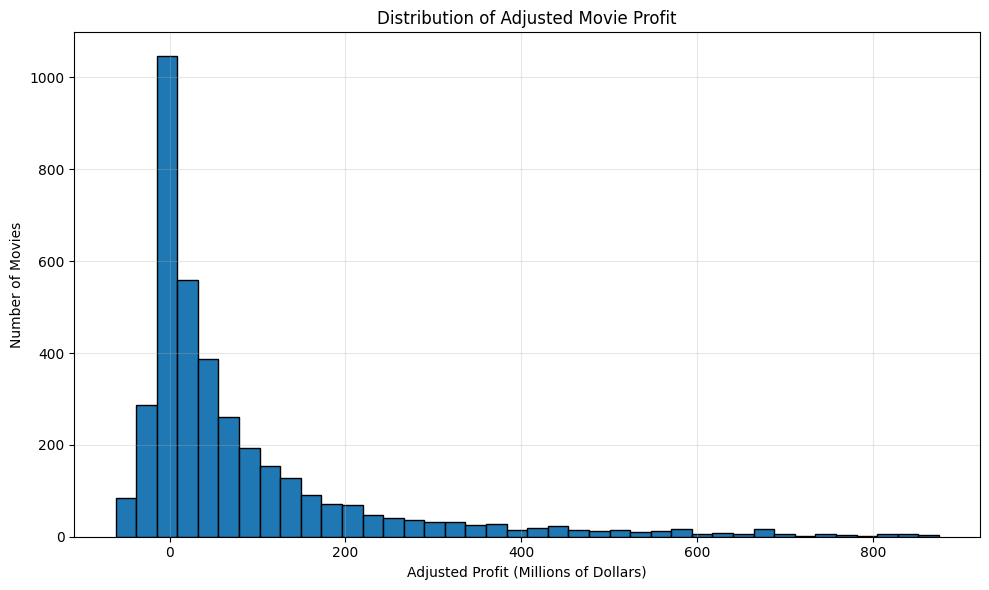

In [15]:
# Histogram of adjusted profit.
# The x-axis is limited to the 1st and 99th percentiles so the main distribution is easier to see.
lower_limit = profit_movies['profit_adj_millions'].quantile(0.01)
upper_limit = profit_movies['profit_adj_millions'].quantile(0.99)

plt.figure(figsize=(10, 6))
plt.hist(profit_movies['profit_adj_millions'], bins=40, range=(lower_limit, upper_limit), edgecolor='black')
plt.title('Distribution of Adjusted Movie Profit')
plt.xlabel('Adjusted Profit (Millions of Dollars)')
plt.ylabel('Number of Movies')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Ten movies with the highest adjusted profit
top_profit_movies = profit_movies.nlargest(10, 'profit_adj')[[
    'original_title', 'release_year', 'budget_adj_millions', 'revenue_adj_millions',
    'profit_adj_millions', 'popularity', 'vote_average', 'vote_count', 'runtime'
]]

top_profit_movies

,original_title,release_year,budget_adj_millions,revenue_adj_millions,profit_adj_millions,popularity,vote_average,vote_count,runtime
1329,Star Wars,1977,39.58,"2,789.71","2,750.14",12.04,7.90,4428,121
1386,Avatar,2009,240.89,"2,827.12","2,586.24",9.43,7.10,8458,162
5231,Titanic,1997,271.69,"2,506.41","2,234.71",4.36,7.30,4654,194
10594,The Exorcist,1973,39.29,"2,167.32","2,128.04",2.01,7.20,1113,122
9806,Jaws,1975,28.36,"1,907.01","1,878.64",2.56,7.30,1415,124
8889,E.T. the Extra-Terrestrial,1982,23.73,"1,791.69","1,767.97",2.90,7.20,1830,115
3,Star Wars: The Force Awakens,2015,184.00,"1,902.72","1,718.72",11.17,7.50,5292,136
8094,The Net,1995,31.48,"1,583.05","1,551.57",1.14,5.60,201,114
10110,One Hundred and One Dalmatians,1961,29.18,"1,574.81","1,545.64",2.63,6.60,913,79
7309,The Empire Strikes Back,1980,47.63,"1,424.63","1,377.00",5.49,8.00,3954,124


The adjusted profit distribution is wide and skewed. The median adjusted profit is much lower than the mean adjusted profit, which shows that a small number of very high-profit movies pull the average upward. About 72% of the movies in the profit dataset have positive adjusted profit.

### Research Question 2: Do higher adjusted budgets relate to higher adjusted profits?

Next, I will compare adjusted budget to adjusted profit. This helps show whether more expensive movies tend to earn more profit after adjusting for inflation.

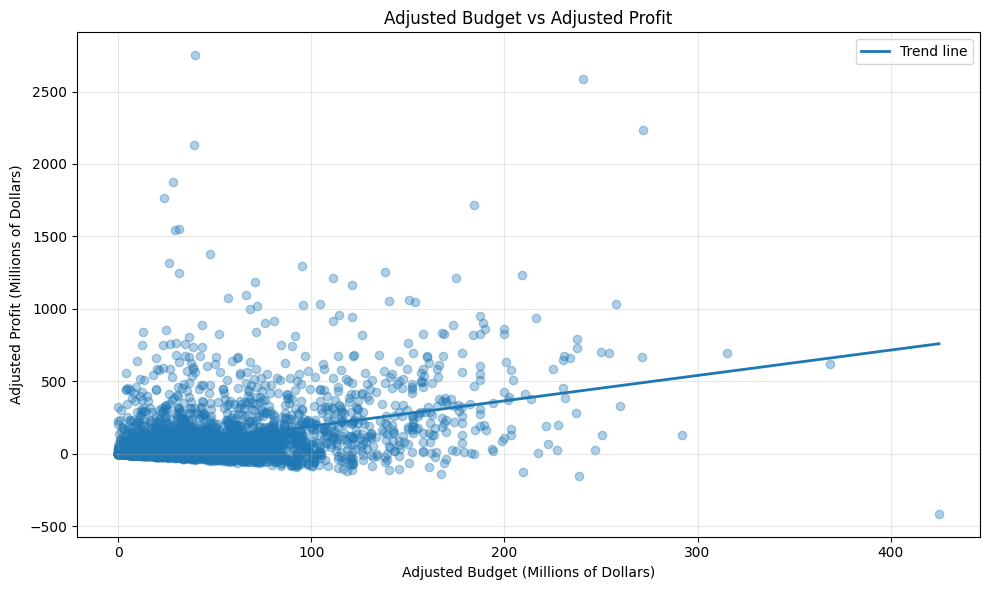

In [17]:
scatter_with_trend(
    profit_movies,
    'budget_adj_millions',
    'profit_adj_millions',
    'Adjusted Budget vs Adjusted Profit',
    'Adjusted Budget (Millions of Dollars)',
    'Adjusted Profit (Millions of Dollars)'
)

In [18]:
# Create budget groups using quintiles
budget_labels = ['Very low', 'Low', 'Medium', 'High', 'Very high']
profit_movies['budget_level'] = pd.qcut(
    profit_movies['budget_adj'],
    q=5,
    labels=budget_labels
)

budget_summary = summarize_profit_by_category(profit_movies, 'budget_level')
budget_summary

,movie_count,mean_profit_millions,median_profit_millions,profitable_rate
budget_level,,,,
Very low,773,25.63,3.37,0.65
Low,769,46.24,18.74,0.72
Medium,770,79.81,32.73,0.71
High,774,100.07,43.93,0.72
Very high,768,212.85,133.95,0.81


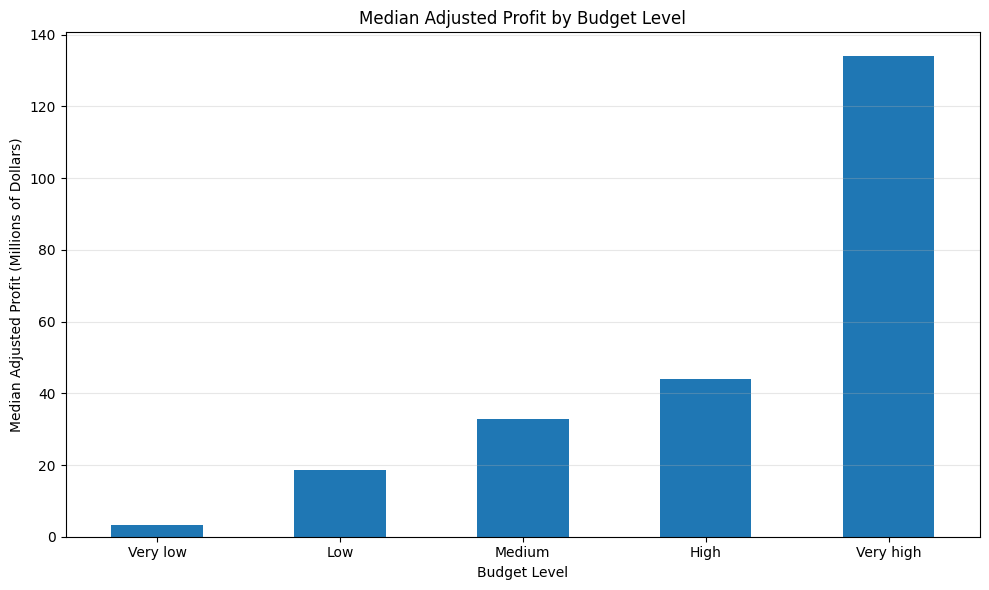

In [19]:
# Bar chart of median adjusted profit by budget level
budget_summary['median_profit_millions'].plot(kind='bar', figsize=(10, 6))
plt.title('Median Adjusted Profit by Budget Level')
plt.xlabel('Budget Level')
plt.ylabel('Median Adjusted Profit (Millions of Dollars)')
plt.xticks(rotation=0)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The scatter plot shows a positive relationship between adjusted budget and adjusted profit, but there is also a lot of variation. Some high-budget movies earned very large profits, while others lost money.

The budget group summary gives a clearer view. Movies in the very high budget group have the highest median adjusted profit and the highest profitable rate. This suggests that larger budgets are associated with stronger profits in this dataset, but a higher budget does not guarantee a profitable movie.

## Research Question 3: How do popularity and user engagement relate to adjusted profit?
This section compares adjusted profit with popularity, vote count, and vote average. These variables represent different forms of audience attention or audience response.

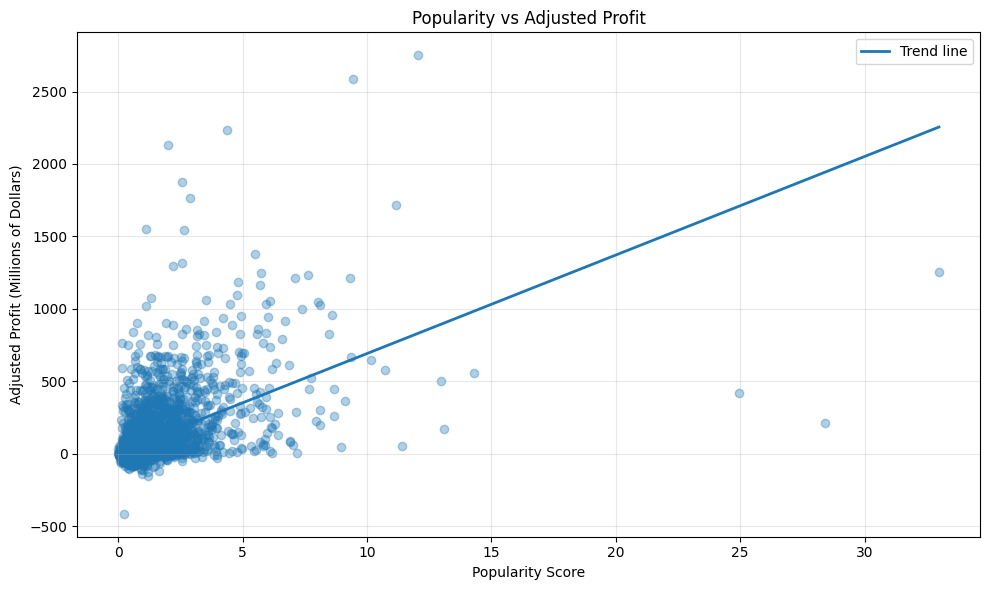

In [20]:
scatter_with_trend(
    profit_movies,
    'popularity',
    'profit_adj_millions',
    'Popularity vs Adjusted Profit',
    'Popularity Score',
    'Adjusted Profit (Millions of Dollars)'
)

In [21]:
# Create popularity groups using quintiles
popularity_labels = ['Very low', 'Low', 'Medium', 'High', 'Very high']
profit_movies['popularity_level'] = pd.qcut(
    profit_movies['popularity'],
    q=5,
    labels=popularity_labels
)

popularity_summary = summarize_profit_by_category(profit_movies, 'popularity_level')
popularity_summary

,movie_count,mean_profit_millions,median_profit_millions,profitable_rate
popularity_level,,,,
Very low,771,15.51,0.10,0.51
Low,771,26.69,6.78,0.59
Medium,770,52.29,21.01,0.70
High,771,103.08,59.80,0.85
Very high,771,266.51,161.92,0.95


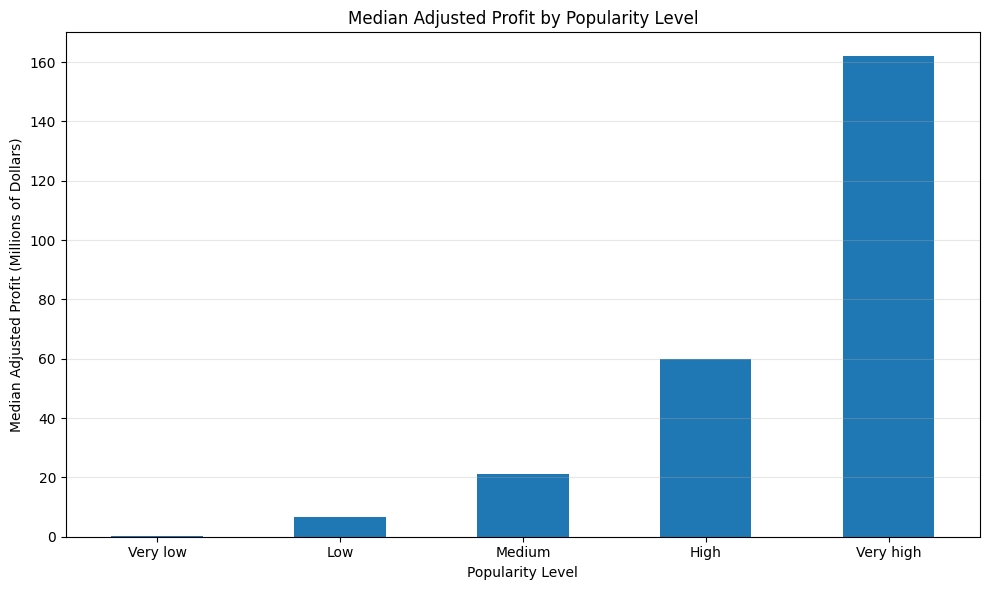

In [22]:
# Bar chart of median adjusted profit by popularity level
popularity_summary['median_profit_millions'].plot(kind='bar', figsize=(10, 6))
plt.title('Median Adjusted Profit by Popularity Level')
plt.xlabel('Popularity Level')
plt.ylabel('Median Adjusted Profit (Millions of Dollars)')
plt.xticks(rotation=0)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

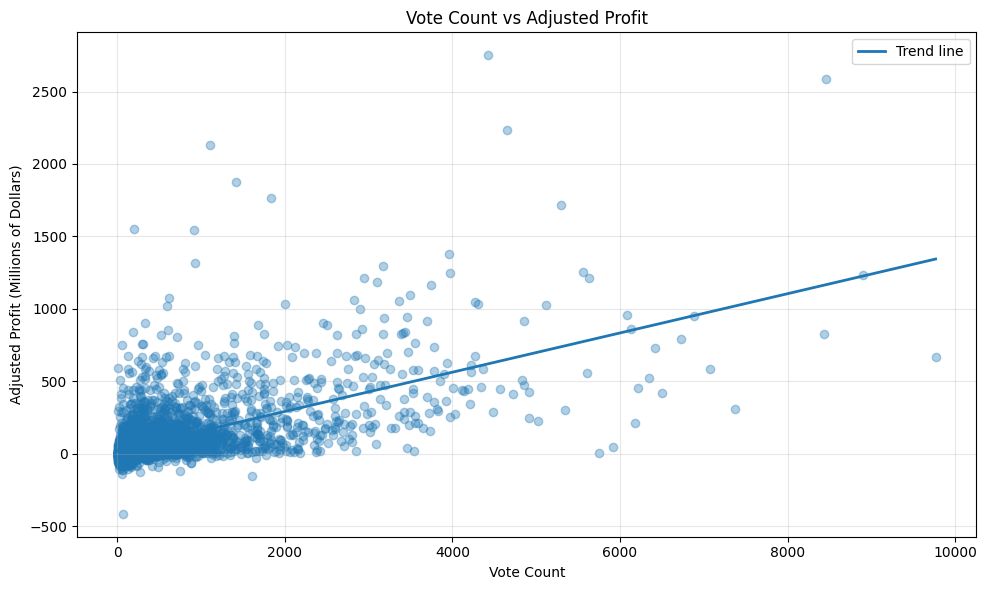

In [23]:
scatter_with_trend(
    profit_movies,
    'vote_count',
    'profit_adj_millions',
    'Vote Count vs Adjusted Profit',
    'Vote Count',
    'Adjusted Profit (Millions of Dollars)'
)

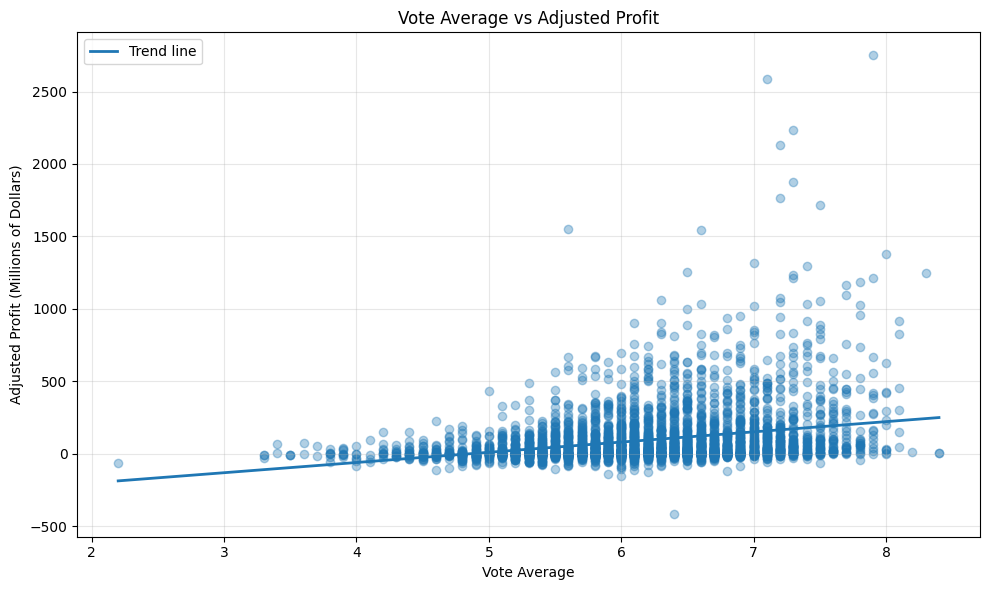

In [24]:
scatter_with_trend(
    profit_movies,
    'vote_average',
    'profit_adj_millions',
    'Vote Average vs Adjusted Profit',
    'Vote Average',
    'Adjusted Profit (Millions of Dollars)'
)

In [25]:
# Correlation table for adjusted profit and selected numeric variables
correlation_columns = [
    'profit_adj', 'budget_adj', 'popularity', 'vote_count', 'vote_average'
]

profit_correlations = profit_movies[correlation_columns].corr(numeric_only=True)['profit_adj'].sort_values(ascending=False)
profit_correlations

profit_adj     1.00
vote_count     0.61
popularity     0.52
budget_adj     0.40
vote_average   0.29
Name: profit_adj, dtype: float64

Popularity and vote count both show a positive relationship with adjusted profit. This makes sense because more profitable movies are often watched by more people, talked about more, and receive more votes.

Vote average also has a positive relationship with adjusted profit, but the relationship is weaker than vote count and popularity. This suggests that the amount of audience engagement may be more strongly associated with profit than the average rating alone.

The correlation table supports this pattern. Vote count and popularity have stronger positive correlations with adjusted profit than vote average.

<a id='conclusions'></a>
## Conclusions

The main goal of this project was to investigate which movie characteristics are associated with higher adjusted profit in the TMDb movie dataset.

The analysis found that adjusted profit varies widely. The median adjusted profit is much lower than the mean adjusted profit because a small number of blockbuster movies earned extremely large profits. About 72% of movies in the cleaned profit dataset had positive adjusted profit.

Higher adjusted budgets are associated with higher adjusted profits, especially when movies are grouped into budget levels. The very high budget group had the highest median adjusted profit and the highest profitable rate. However, some high-budget movies still lost money, so budget alone does not guarantee success.

Popularity and vote count showed stronger positive relationships with adjusted profit than vote average. This suggests that audience attention and engagement are more closely connected to profit than rating score alone. Vote average still had a positive relationship, but it was weaker.

Overall, the variables most associated with higher adjusted profit in this analysis were adjusted budget, popularity, and vote count. These findings show relationships in the data, but they do not prove causation.

## Limitations

There are several limitations in this analysis.

First, many movies in the original dataset had zero values for budget or revenue. These values likely represent missing financial data instead of true zero-dollar budgets or revenues. Because adjusted profit depends on both budget and revenue, those rows had to be removed from the profit analysis. This reduced the dataset from 10,866 movies to 3,854 movies, which may create bias if the remaining movies are mostly larger or better-documented releases.

Second, the dataset does not include every cost or revenue source that affects real movie profit. Marketing costs, distribution costs, streaming revenue, international release differences, and later licensing deals are not included. Because of this, `revenue_adj - budget_adj` is only an estimate of profit, not a complete business profit calculation.

Third, the popularity score comes from TMDb and may be influenced by user activity on that platform. It may not perfectly represent general audience popularity across all countries, theaters, or time periods.

Finally, this project is exploratory and does not use statistical tests or controlled experiments. The results describe patterns and correlations, not cause-and-effect relationships.

In [26]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 947382 bytes to Investigate_a_Dataset.html
